In [ ]:
import sys
%pip install google-play-scraper
%pip install emoji
%pip install google-play-scraper pandas
%pip install transformers datasets accelerate evaluate emoji huggingface_hub -U
%pip install torch
%pip install matplotlib
%pip install seaborn
%pip install imbalanced-learn
%pip install langdetect

In [ ]:
from google_play_scraper import Sort, reviews
import pandas as pd
from datetime import datetime
import time
from langdetect import detect

def is_ulasan_valid(text):
    teks_str = str(text).lower()  
    try:
        if len(teks_str.split()) < 3:
            return True 
            
        bahasa = detect(teks_str)
        if bahasa == 'en':
            return False
            
        return True
    except:
        return True

def scrape_playstore_by_date_range(app_id, start_date_str, end_date_str, lang='id', country='id'):
    start_date = datetime.strptime(start_date_str, "%Y-%m-%d")
    end_date = datetime.strptime(end_date_str, "%Y-%m-%d")

    print(f"Game: {app_id}")
    print(f"Target rentang waktu: {start_date_str} s/d {end_date_str}...")

    hasil_ulasan = []
    continuation_token = None
    batch_size = 1000

    while True:
        result, continuation_token = reviews(
            app_id,
            lang=lang,
            country=country,
            sort=Sort.NEWEST,
            count=batch_size,
            continuation_token=continuation_token
        )
        if not result:
            break

        hasil_ulasan.extend(result)
        oldest_date_in_batch = result[-1]['at'].replace(tzinfo=None)
        if oldest_date_in_batch < start_date:
            break
        time.sleep(1)

    df = pd.DataFrame(hasil_ulasan)
    df['at'] = pd.to_datetime(df['at']).dt.tz_localize(None)
    mask = (df['at'] >= start_date) & (df['at'] <= end_date)
    df = df.loc[mask]

    df = df[['userName', 'score', 'at', 'content']]
    df.columns = ['Nama Pengguna', 'Rating', 'Tanggal', 'Ulasan']

    print(f"Selesai! Berhasil mengambil {len(df)} ulasan valid dalam rentang tersebut.")
    return df

# Eksekusi Scraping Wuthering Waves
id_wuwa = 'com.kurogame.wutheringwaves.global'
tgl_mulai = '2026-02-13'
tgl_akhir = '2026-05-13'

print("Scraping Wuthering Waves")
df_wuwa = scrape_playstore_by_date_range(id_wuwa, tgl_mulai, tgl_akhir)
df_wuwa['Game'] = 'Wuthering Waves'

print("\nPreview Data Hasil Scraping (5 Teratas):")
print(df_wuwa.head())

nama_file = 'dataset_ulasan_wuwa_mentah.csv'
df_wuwa.to_csv(nama_file, index=False, encoding='utf-8')
print(f"\nData berhasil disimpan ke dalam file: {nama_file}")

Scraping Wuthering Waves
Game: com.kurogame.wutheringwaves.global
Target rentang waktu: 2025-10-26 s/d 2026-02-22...
Selesai! Berhasil mengambil 3128 ulasan valid dalam rentang tersebut.

Preview Data Hasil Scraping (5 Teratas):
         Nama Pengguna  Rating             Tanggal  \
1457        Steven Nix       1 2026-02-21 23:37:00   
1458   Kazuto Kirigaya       5 2026-02-21 22:38:45   
1459  Abdul Azis Salim       5 2026-02-21 22:11:21   
1460       zexa aldian       5 2026-02-21 21:53:38   
1461    RISKI FITRIADI       3 2026-02-21 20:33:34   

                                                 Ulasan             Game  
1457  quiting for life bcs losing 50 50 11 times in ...  Wuthering Waves  
1458                                          good game  Wuthering Waves  
1459                                             mantap  Wuthering Waves  
1460                                       niceee ooooo  Wuthering Waves  
1461  tolong dong kuro sedia in bahasa indonesia, sa...  Wuthering Wave

Berhasil memuat 2652 data.

[SUCCESS] Preprocessing selesai! Data bersih disimpan di: dataset_ulasan_wuwa_CLEAN.csv


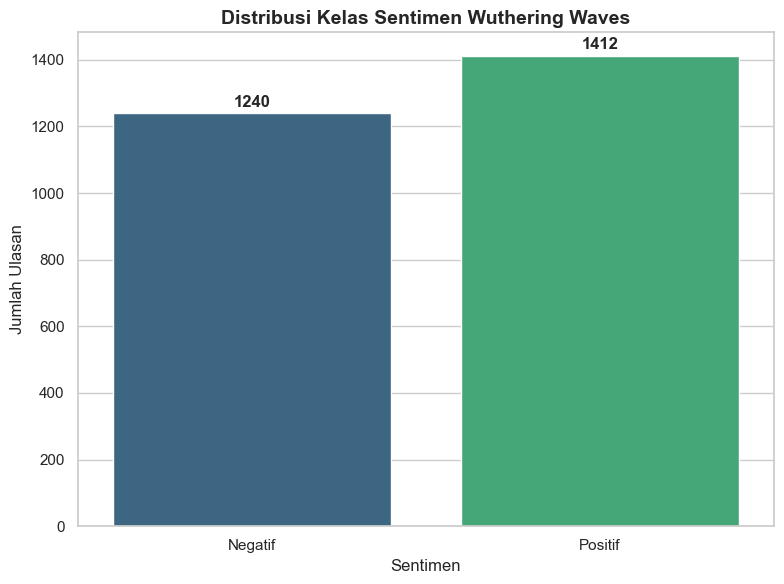

In [3]:
import pandas as pd
import re
import emoji
import requests
import io
import matplotlib.pyplot as plt
import seaborn as sns

def load_data(file_path):
    try:
        df = pd.read_csv(file_path)
        print(f"Berhasil memuat {len(df)} data.")
        return df
    except Exception as e:
        print(f"Gagal memuat file: {e}")
        return None

def muat_kamus_eksternal():
    # Kamus slang
    url_slang = "https://raw.githubusercontent.com/adeariniputri/text-preprocesing/master/slang.csv"
    response_slang = requests.get(url_slang)
    df_slang = pd.read_csv(io.StringIO(response_slang.text))
    kamus_github = dict(zip(df_slang['slang'], df_slang['formal']))

    # Kamus KBBI
    url_kbbi = "https://raw.githubusercontent.com/damzaky/kumpulan-kata-bahasa-indonesia-KBBI/master/list_1.0.0.txt"
    response_kbbi = requests.get(url_kbbi)
    daftar_kbbi = set(response_kbbi.text.split('\n'))
    daftar_kbbi.update(["game", "wuthering", "waves", "developer", "dev", "player", "kuro", "wuwa"])

    # Kamus slang game khusus WuWa/Umum (Tanpa ekspresi tertawa)
    kamus_game = {
        "ampas": "jelek", "burik": "jelek", "kikir": "pelit", "bansos": "hadiah",
        "wuwa": "wuthering waves", "ww": "wuthering waves",
        "gacha": "undian", "pity": "jaminan gacha", "ngelag": "patah patah",
        "force close": "keluar sendiri", "wibu": "penggemar anime", "husbu": "karakter pria",
        "waifu": "karakter wanita", "pensi": "berhenti main", "mulung": "mencari material",
        "p2w": "pay to win", "explorasi": "eksplorasi", "b4": "bintang empat", "b5": "bintang lima",
        "char": "karakter", "rerun": "rilis ulang", "hard pity": "jaminan gacha maksimal",
        "grinding": "mencari material", "experience": "pengalaman", "yg": "yang", "ga": "tidak",
        "gak": "tidak", "gk": "tidak", "nggak": "tidak", "gw": "saya", "gua": "saya",
        "kalo": "kalau", "klo": "kalau", "udh": "sudah", "dah": "sudah", "bgt": "banget",
        "dapet": "dapat", "karna": "karena", "ni": "ini", "nih": "ini", "tuh": "itu",
        "biar": "supaya", "mulu": "terus", "gitu": "begitu", "cuman": "cuma", "doang": "saja",
        "tambahin": "tambahkan", "bikin": "membuat", "pas": "saat", "sampe": "sampai",
        "dikit": "sedikit", "kayak": "seperti", "kek": "seperti", "kaya": "seperti",
        "pake": "pakai", "make": "pakai", "gede": "besar", "hp": "handphone", "device": "perangkat",
        "bug": "masalah teknis", "lag": "patah patah", "fps": "frame per detik", "drop": "turun",
        "kentang": "spesifikasi rendah", "patch": "pembaruan", "update": "pembaruan", "login": "masuk",
        "laggy": "patah patah", "story": "cerita", "quest": "misi", "map": "peta", "event": "acara",
        "gameplay": "permainan", "skip": "lewati", "reward": "hadiah", "kuro": "kuro games",
        "rate off": "kalah gacha", "rate on": "menang gacha", "f2p": "bermain gratis",
        "whale": "pemain sultan", "op": "sangat kuat", "nerf": "penurunan kekuatan", "buff": "peningkatan kekuatan",
        "jd": "jadi","memory": "penyimpanan","memori": "penyimpanan", "storage": "penyimpanan","space": "penyimpanan","ram": "memori","size": "ukuran","update": "pembaruan", "patch": "pembaruan"
    }
    kamus_github.update(kamus_game)
    return kamus_github, daftar_kbbi

KAMUS_SLANG_GABUNGAN, DAFTAR_KBBI = muat_kamus_eksternal()

def preprocess_text(text):
    if not isinstance(text, str): return ""
    text = text.lower()

    # 1. Menghapus URL, Mention, Hashtag, dan Angka
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'\@\w+|\#', '', text)
    text = re.sub(r'\d+', '', text)

    # 2. Demojize
    text = emoji.demojize(text, language='id')
    text = text.replace(':', ' ').replace('_', ' ')

    # 3. Ganti SEMUA tanda baca dengan spasi agar tidak menempel pada kata
    text = re.sub(r'[^\w\s]', ' ', text)

    # 4. Normalisasi kata
    words = text.split()
    normalized_words = []
    for word in words:
        if word in KAMUS_SLANG_GABUNGAN:
            normalized_words.append(KAMUS_SLANG_GABUNGAN[word])
        else:
            normalized_words.append(word)

    text = " ".join(normalized_words)
    return re.sub(r'\s+', ' ', text).strip()


input_filename = 'Dataset_WUWA_1026_222.csv'
output_filename = 'dataset_ulasan_wuwa_CLEAN.csv'

df_labeled = load_data(input_filename)

if df_labeled is not None and 'Sentimen' in df_labeled.columns:
    df_labeled['Ulasan_Clean'] = df_labeled['Ulasan'].apply(preprocess_text)

    df_labeled = df_labeled[df_labeled['Ulasan_Clean'] != ""]
    df_labeled = df_labeled.dropna(subset=['Ulasan_Clean', 'Sentimen'])

    cols = ['Nama Pengguna', 'Rating', 'Tanggal', 'Game', 'Ulasan', 'Ulasan_Clean', 'Sentimen']
    existing_cols = [c for c in cols if c in df_labeled.columns]
    df_final = df_labeled[existing_cols]

    df_final.to_csv(output_filename, index=False, encoding='utf-8')
    print(f"\n[SUCCESS] Preprocessing selesai! Data bersih disimpan di: {output_filename}")

    # Visualisasi Sentimen
    plt.figure(figsize=(8, 6))
    sns.set_theme(style="whitegrid")
    ax = sns.countplot(data=df_final, x='Sentimen', order=['Negatif', 'Positif'], hue='Sentimen', palette='viridis', legend=False)
    ax.set_title('Distribusi Kelas Sentimen Wuthering Waves', fontsize=14, fontweight='bold')
    ax.set_ylabel('Jumlah Ulasan', fontsize=12)
    ax.set_xlabel('Sentimen', fontsize=12)

    # Tambahkan label angka di atas bar
    for p in ax.patches:
        height = p.get_height()
        if not pd.isna(height) and height > 0:
            ax.annotate(f'{int(height)}', (p.get_x() + p.get_width() / 2., height),
                        ha='center', va='center', xytext=(0, 8), textcoords='offset points', fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("Kolom 'Sentimen' tidak ditemukan atau file gagal dimuat")

In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split

def execute_sentiment_splitting_80_10_10(input_file):
    nama_metode = "80_10_10"
    try:
        df = pd.read_csv(input_file)
        df = df.dropna(subset=['Sentimen'])

        print("="*60)
        print("ANALISIS DATASET SEBELUM SPLIT".center(60))
        print("="*60)
        print(f"Total data      : {len(df)}")
        print("\nDistribusi Sentimen:")
        print(df['Sentimen'].value_counts().to_string())

        # Splitting
        train_df, temp_df = train_test_split(
            df, test_size=0.20,
            random_state=42,
            stratify=df['Sentimen'],
            shuffle=True
        )
        val_df, test_df = train_test_split(
            temp_df, test_size=0.50,
            random_state=42,
            stratify=temp_df['Sentimen'],
            shuffle=True
        )

        print("\n" + "="*60)
        print(f"SPLIT {nama_metode}".center(60))
        print("="*60)

        total_len = len(df)
        print(f"Train : {len(train_df)} baris ({(len(train_df)/total_len)*100:.1f}%)")
        print(f"Val   : {len(val_df)} baris ({(len(val_df)/total_len)*100:.1f}%)")
        print(f"Test  : {len(test_df)} baris ({(len(test_df)/total_len)*100:.1f}%)\n")

        # Cek Leak
        train_idx, val_idx, test_idx = set(train_df.index), set(val_df.index), set(test_df.index)
        print("Cek Kebocoran Data (Data Leakage):")
        print(f"Train ∩ Val  = {len(train_idx.intersection(val_idx))}")
        print(f"Train ∩ Test = {len(train_idx.intersection(test_idx))}")
        print(f"Val   ∩ Test = {len(val_idx.intersection(test_idx))}\n")

        # Simpan file
        train_df.to_csv(f'train_{nama_metode}.csv', index=False)
        val_df.to_csv(f'val_{nama_metode}.csv', index=False)
        test_df.to_csv(f'test_{nama_metode}.csv', index=False)
        print(f"[SUCCESS] File CSV split berhasil disimpan!")

    except Exception as e:
        print(f"[ERROR] Split {nama_metode} gagal: {e}")

file_dataset = 'dataset_ulasan_wuwa_CLEAN.csv'
execute_sentiment_splitting_80_10_10(input_file=file_dataset)

               ANALISIS DATASET SEBELUM SPLIT               
Total data      : 2652

Distribusi Sentimen:
Sentimen
Positif    1412
Negatif    1240

                       SPLIT 80_10_10                       
Train : 2121 baris (80.0%)
Val   : 265 baris (10.0%)
Test  : 266 baris (10.0%)

Cek Kebocoran Data (Data Leakage):
Train ∩ Val  = 0
Train ∩ Test = 0
Val   ∩ Test = 0

[SUCCESS] File CSV split berhasil disimpan!


In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split

def execute_sentiment_splitting_70_15_15(input_file):
    nama_metode = "70_15_15"
    try:
        df = pd.read_csv(input_file)
        df = df.dropna(subset=['Sentimen'])

        print("="*60)
        print("ANALISIS DATASET SEBELUM SPLIT".center(60))
        print("="*60)
        print(f"Total data      : {len(df)}")
        print("\nDistribusi Sentimen:")
        print(df['Sentimen'].value_counts().to_string())

        # Splitting
        train_df, temp_df = train_test_split(
            df, 
            test_size=0.30, 
            random_state=42, 
            stratify=df['Sentimen'], 
            shuffle=True
        )

        val_df, test_df = train_test_split(
            temp_df, 
            test_size=0.50,
            random_state=42, 
            stratify=temp_df['Sentimen'], 
            shuffle=True
        )

        print("\n" + "="*60)
        print(f"SPLIT {nama_metode}".center(60))
        print("="*60)

        total_len = len(df)
        print(f"Train : {len(train_df)} baris ({(len(train_df)/total_len)*100:.1f}%)")
        print(f"Val   : {len(val_df)} baris ({(len(val_df)/total_len)*100:.1f}%)")
        print(f"Test  : {len(test_df)} baris ({(len(test_df)/total_len)*100:.1f}%)\n")

        # Cek Leak
        train_idx, val_idx, test_idx = set(train_df.index), set(val_df.index), set(test_df.index)
        print("Cek Kebocoran Data (Data Leakage):")
        print(f"Train ∩ Val  = {len(train_idx.intersection(val_idx))}")
        print(f"Train ∩ Test = {len(train_idx.intersection(test_idx))}")
        print(f"Val   ∩ Test = {len(val_idx.intersection(test_idx))}\n")

        # Simpan file
        train_df.to_csv(f'train_{nama_metode}.csv', index=False)
        val_df.to_csv(f'val_{nama_metode}.csv', index=False)
        test_df.to_csv(f'test_{nama_metode}.csv', index=False)
        print(f"[SUCCESS] File CSV split berhasil disimpan!")

    except Exception as e:
        print(f"[ERROR] Split {nama_metode} gagal: {e}")

file_dataset = 'dataset_ulasan_wuwa_CLEAN.csv'
execute_sentiment_splitting_70_15_15(input_file=file_dataset)
import pandas as pd
from sklearn.model_selection import train_test_split

def execute_sentiment_splitting_70_15_15(input_file):
    nama_metode = "70_15_15"
    try:
        df = pd.read_csv(input_file)
        df = df.dropna(subset=['Sentimen'])

        print("="*60)
        print("ANALISIS DATASET SEBELUM SPLIT".center(60))
        print("="*60)
        print(f"Total data      : {len(df)}")
        print("\nDistribusi Sentimen:")
        print(df['Sentimen'].value_counts().to_string())

        # Splitting
        train_df, temp_df = train_test_split(
            df, 
            test_size=0.30, 
            random_state=42, 
            stratify=df['Sentimen'], 
            shuffle=True
        )

        val_df, test_df = train_test_split(
            temp_df, 
            test_size=0.50,
            random_state=42, 
            stratify=temp_df['Sentimen'], 
            shuffle=True
        )

        print("\n" + "="*60)
        print(f"SPLIT {nama_metode}".center(60))
        print("="*60)

        total_len = len(df)
        print(f"Train : {len(train_df)} baris ({(len(train_df)/total_len)*100:.1f}%)")
        print(f"Val   : {len(val_df)} baris ({(len(val_df)/total_len)*100:.1f}%)")
        print(f"Test  : {len(test_df)} baris ({(len(test_df)/total_len)*100:.1f}%)\n")

        # Cek Leak
        train_idx, val_idx, test_idx = set(train_df.index), set(val_df.index), set(test_df.index)
        print("Cek Kebocoran Data (Data Leakage):")
        print(f"Train ∩ Val  = {len(train_idx.intersection(val_idx))}")
        print(f"Train ∩ Test = {len(train_idx.intersection(test_idx))}")
        print(f"Val   ∩ Test = {len(val_idx.intersection(test_idx))}\n")

        # Simpan file
        train_df.to_csv(f'train_{nama_metode}.csv', index=False)
        val_df.to_csv(f'val_{nama_metode}.csv', index=False)
        test_df.to_csv(f'test_{nama_metode}.csv', index=False)
        print(f"[SUCCESS] File CSV split berhasil disimpan!")

    except Exception as e:
        print(f"[ERROR] Split {nama_metode} gagal: {e}")

file_dataset = 'dataset_ulasan_wuwa_CLEAN.csv'
execute_sentiment_splitting_70_15_15(input_file=file_dataset)

               ANALISIS DATASET SEBELUM SPLIT               
Total data      : 2652

Distribusi Sentimen:
Sentimen
Positif    1412
Negatif    1240

                       SPLIT 70_15_15                       
Train : 1856 baris (70.0%)
Val   : 398 baris (15.0%)
Test  : 398 baris (15.0%)

Cek Kebocoran Data (Data Leakage):
Train ∩ Val  = 0
Train ∩ Test = 0
Val   ∩ Test = 0

[SUCCESS] File CSV split berhasil disimpan!
               ANALISIS DATASET SEBELUM SPLIT               
Total data      : 2652

Distribusi Sentimen:
Sentimen
Positif    1412
Negatif    1240

                       SPLIT 70_15_15                       
Train : 1856 baris (70.0%)
Val   : 398 baris (15.0%)
Test  : 398 baris (15.0%)

Cek Kebocoran Data (Data Leakage):
Train ∩ Val  = 0
Train ∩ Test = 0
Val   ∩ Test = 0

[SUCCESS] File CSV split berhasil disimpan!


In [6]:
import pandas as pd
from sklearn.model_selection import train_test_split

def execute_sentiment_splitting_60_20_20(input_file):
    nama_metode = "60_20_20"
    try:
        df = pd.read_csv(input_file)
        df = df.dropna(subset=['Sentimen'])

        print("="*60)
        print("ANALISIS DATASET SEBELUM SPLIT".center(60))
        print("="*60)
        print(f"Total data      : {len(df)}")
        print("\nDistribusi Sentimen:")
        print(df['Sentimen'].value_counts().to_string())

        # Splitting
        train_df, temp_df = train_test_split(
            df, test_size=0.40, random_state=42, stratify=df['Sentimen'], shuffle=True
        )
        val_df, test_df = train_test_split(
            temp_df, test_size=0.50, random_state=42, stratify=temp_df['Sentimen'], shuffle=True
        )

        print("\n" + "="*60)
        print(f"SPLIT {nama_metode}".center(60))
        print("="*60)

        total_len = len(df)
        print(f"Train : {len(train_df)} baris ({(len(train_df)/total_len)*100:.1f}%)")
        print(f"Val   : {len(val_df)} baris ({(len(val_df)/total_len)*100:.1f}%)")
        print(f"Test  : {len(test_df)} baris ({(len(test_df)/total_len)*100:.1f}%)\n")

        # Cek Leak
        train_idx, val_idx, test_idx = set(train_df.index), set(val_df.index), set(test_df.index)
        print("Cek Kebocoran Data (Data Leakage):")
        print(f"Train ∩ Val  = {len(train_idx.intersection(val_idx))}")
        print(f"Train ∩ Test = {len(train_idx.intersection(test_idx))}")
        print(f"Val   ∩ Test = {len(val_idx.intersection(test_idx))}\n")

        # Simpan file
        train_df.to_csv(f'train_{nama_metode}.csv', index=False)
        val_df.to_csv(f'val_{nama_metode}.csv', index=False)
        test_df.to_csv(f'test_{nama_metode}.csv', index=False)
        print(f"[SUCCESS] File CSV split berhasil disimpan!")

    except Exception as e:
        print(f"[ERROR] Split {nama_metode} gagal: {e}")

file_dataset = 'dataset_ulasan_wuwa_CLEAN.csv'
execute_sentiment_splitting_60_20_20(input_file=file_dataset)

               ANALISIS DATASET SEBELUM SPLIT               
Total data      : 2652

Distribusi Sentimen:
Sentimen
Positif    1412
Negatif    1240

                       SPLIT 60_20_20                       
Train : 1591 baris (60.0%)
Val   : 530 baris (20.0%)
Test  : 531 baris (20.0%)

Cek Kebocoran Data (Data Leakage):
Train ∩ Val  = 0
Train ∩ Test = 0
Val   ∩ Test = 0

[SUCCESS] File CSV split berhasil disimpan!


In [ ]:
import random
import os
import gc
import shutil
import pandas as pd
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.utils.data import Dataset
from torch import nn
from transformers import AutoTokenizer, AutoModel, TrainingArguments, Trainer, EarlyStoppingCallback
from sklearn.metrics import f1_score, accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


#LOAD DATASET & PREPARATION
train_df = pd.read_csv('train_80_10_10.csv')
val_df   = pd.read_csv('val_80_10_10.csv')
test_df  = pd.read_csv('test_80_10_10.csv')

sentimen_map = {'Negatif': 0, 'Positif': 1}

def prepare_labels(df):
    df = df.copy()
    df['label_sent'] = df['Sentimen'].map(sentimen_map)
    return df

train_df = prepare_labels(train_df)
val_df   = prepare_labels(val_df)
test_df  = prepare_labels(test_df)

print(f"Train : {len(train_df)} | Val : {len(val_df)} | Test : {len(test_df)}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


#TOKENIZER & DATASET
model_name = "indolem/indobertweet-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

class SentimentDataset(Dataset):
    def __init__(self, df, tokenizer, max_length=128):
        texts = df['Ulasan_Clean'].astype(str).tolist()
        self.labels_sent = df['label_sent'].tolist()

        self.encodings = tokenizer(
            texts,
            max_length=max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item['labels_sent'] = torch.tensor(self.labels_sent[idx], dtype=torch.long)
        return item

    def __len__(self):
        return len(self.labels_sent)

train_dataset = SentimentDataset(train_df, tokenizer, max_length=128)
val_dataset   = SentimentDataset(val_df,   tokenizer, max_length=128)
test_dataset  = SentimentDataset(test_df,  tokenizer, max_length=128)


#ARSITEKTUR MODEL
class SentimentIndoBERTweet(nn.Module):
    def __init__(self):
        super(SentimentIndoBERTweet, self).__init__()
        self.bert = AutoModel.from_pretrained(model_name)
        self.dropout = nn.Dropout(0.3)
        self.classifier_sent = nn.Linear(768, 2)

    def forward(self, input_ids, attention_mask, labels_sent=None):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls_output = outputs.last_hidden_state[:, 0, :]
        cls_output = self.dropout(cls_output)
        logits_sent = self.classifier_sent(cls_output)

        loss = None
        if labels_sent is not None:
            loss_fct = nn.CrossEntropyLoss()
            loss = loss_fct(logits_sent, labels_sent)

        return {"loss": loss, "logits_sent": logits_sent} if loss is not None else logits_sent


#COMPUTE METRICS

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    if isinstance(logits, tuple):
        logits = logits[0]
    preds = np.argmax(logits, axis=1)

    acc    = accuracy_score(labels, preds)
    f1_mac = f1_score(labels, preds, average='macro')

    return {
        "accuracy": acc,
        "f1_macro": f1_mac,
    }

class SentimentTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels_sent = inputs.pop("labels_sent")
        outputs = model(**inputs, labels_sent=labels_sent)
        loss = outputs["loss"]
        return (loss, outputs) if return_outputs else loss

    def prediction_step(self, model, inputs, prediction_loss_only, ignore_keys=None):
        labels_sent = inputs.pop("labels_sent")
        inputs = self._prepare_inputs(inputs)
        labels_sent = labels_sent.to(self.args.device)

        with torch.no_grad():
            outputs = model(**inputs, labels_sent=labels_sent)
            loss    = outputs["loss"]
            logits  = outputs["logits_sent"]

        if prediction_loss_only:
            return (loss, None, None)
        return (loss, logits, labels_sent)


#SETUP HYPERPARAMETER GRID
epochs_list = [2, 3, 4, 5]
lr_list = [1e-5, 2e-5, 3e-5, 4e-5, 5e-5]
batch_sizes = [16, 32]

hyperparameter_grid = []
scenario_num = 1

for e in epochs_list:
    for lr in lr_list:
        for b in batch_sizes:
            hyperparameter_grid.append({
                'scenario': scenario_num,
                'epochs': e,
                'lr': lr,
                'batch_size': b
            })
            scenario_num += 1

print("\n" + "="*60)
print(f"MEMULAI EKSPERIMEN ({len(hyperparameter_grid)} SKENARIO)")
print("="*60)

results_list = []


#LOOPING TRAINING
best_overall_f1 = 0
best_overall_scenario = None

for hp in hyperparameter_grid:
    output_dir = f"./temp_hasil_skenario_{hp['scenario']}"
    print(f"\nMENJALANKAN SKENARIO {hp['scenario']}/{len(hyperparameter_grid)} | Epochs={hp['epochs']}, LR={hp['lr']}, Batch={hp['batch_size']}")

    set_seed(42)
    model = SentimentIndoBERTweet().to(device)

    training_args = TrainingArguments(
        output_dir=output_dir,
        num_train_epochs=hp['epochs'],
        learning_rate=hp['lr'],
        per_device_train_batch_size=hp['batch_size'],
        per_device_eval_batch_size=32,
        eval_strategy="epoch",
        save_strategy="epoch",
        save_total_limit=1,
        load_best_model_at_end=True,
        metric_for_best_model="f1_macro",
        greater_is_better=True,
        warmup_ratio=0.1,
        weight_decay=0.01,
        logging_dir=None,
        logging_steps=50,
        fp16=torch.cuda.is_available(),
        report_to="none"
    )

    trainer = SentimentTrainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
    )

    trainer.train()

    # Evaluasi ke data Testing
    eval_result = trainer.evaluate(test_dataset)

    best_f1  = eval_result['eval_f1_macro']
    best_acc = eval_result['eval_accuracy']
    best_loss = eval_result['eval_loss']

    results_list.append({
        'Skenario': hp['scenario'],
        'Epochs': hp['epochs'],
        'Learning Rate': hp['lr'],
        'Batch Size': hp['batch_size'],
        'Test_Loss': best_loss,
        'Test_Akurasi': best_acc,
        'Test_F1_Macro': best_f1
    })

    print(f"Skenario {hp['scenario']} Selesai | Test_Loss: {best_loss:.4f} | Test_F1_Macro: {best_f1:.4f}")

  #save model
    if best_f1 > best_overall_f1:
        best_overall_f1 = best_f1
        best_overall_scenario = hp['scenario']

        # Simpan model terbaik
        best_model_dir = "./model_terbaik"
        os.makedirs(best_model_dir, exist_ok=True)
        torch.save(model.state_dict(), f"{best_model_dir}/model.pth")
        tokenizer.save_pretrained(best_model_dir)

        with open(f"{best_model_dir}/info_terbaik.txt", "w") as f:
            f.write(f"Skenario : {hp['scenario']}\n")
            f.write(f"Epochs   : {hp['epochs']}\n")
            f.write(f"LR       : {hp['lr']}\n")
            f.write(f"Batch    : {hp['batch_size']}\n")
            f.write(f"F1-Macro : {best_f1:.4f}\n")
            f.write(f"Accuracy : {best_acc:.4f}\n")
            f.write(f"Loss     : {best_loss:.4f}\n")

        print(f"MODEL TERBAIK BARU! F1={best_f1:.4f} disimpan di {best_model_dir}")

     #evaluasi 
        pred_output = trainer.predict(test_dataset)
        preds  = np.argmax(pred_output.predictions, axis=1)
        labels = pred_output.label_ids

        # Classification Report
        print("\n" + "="*50)
        print(f"CLASSIFICATION REPORT — Skenario {hp['scenario']}")
        print("="*50)
        report = classification_report(
            labels, preds,
            target_names=['Negatif', 'Positif'],
            digits=4
        )
        print(report)

        # Simpan classification report ke file txt
        with open(f"{best_model_dir}/classification_report.txt", "w") as f:
            f.write(f"Skenario {hp['scenario']} | Epochs={hp['epochs']}, LR={hp['lr']}, Batch={hp['batch_size']}\n")
            f.write("="*50 + "\n")
            f.write(report)

        # Confusion Matrix
        cm = confusion_matrix(labels, preds)
        disp = ConfusionMatrixDisplay(
            confusion_matrix=cm,
            display_labels=['Negatif', 'Positif']
        )
        fig, ax = plt.subplots(figsize=(5, 4))
        disp.plot(cmap='Blues', ax=ax)
        ax.set_title(
            f'Confusion Matrix — Skenario {hp["scenario"]}\n'
            f'Epochs={hp["epochs"]}, LR={hp["lr"]}, Batch={hp["batch_size"]}'
        )
        plt.tight_layout()
        plt.savefig(f'{best_model_dir}/confusion_matrix.png', dpi=150, bbox_inches='tight')
        plt.show()
        print(f"[SAVED] confusion_matrix.png & classification_report.txt tersimpan di {best_model_dir}")

    # Hapus folder temp
    if os.path.exists(output_dir):
        shutil.rmtree(output_dir)
        print(f"Folder {output_dir} dihapus")

    del model
    del trainer
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

# ==========================================
# 7. CETAK DAN SIMPAN HASIL REKAPITULASI
# ==========================================
df_results = pd.DataFrame(results_list)

df_results = df_results.sort_values(
    by=['Test_F1_Macro', 'Test_Loss'],
    ascending=[False, True]
).reset_index(drop=True)

print("\n" + "="*60)
print("HASIL AKHIR EKSPERIMEN")
print("="*60)
print(df_results.to_string())

df_results.to_csv('rekap_eksperimen_anti_overfitting.csv', index=False)
print("\nSELURUH PROSES SELESAI!")